In [1]:
import numpy as np
from numpy import linalg as la
np.set_printoptions(suppress=True)

A = np.array([[1, 2, 3],[0, -4, 1],[0, 3, -1]])

det=la.det(A)
print(det)

b=np.array([2, 2, -1])
xA_b=np.linalg.solve(A, b)
print(f'(x,y,z) is {xA_b}')
is_orthogonal = np.allclose(A.T, la.inv(A))
print(is_orthogonal)

# A*v=lambda*v, therefore la.eig(a)=lambda + eig vectors
Lambda, v = la.eig(A)
print(Lambda)
print(v)

1.0
(x,y,z) is [10. -1. -2.]
False
[ 1.         -4.79128785 -0.20871215]
[[ 1.         -0.05055961  0.94256676]
 [ 0.         -0.78318743 -0.08518794]
 [ 0.          0.6197267  -0.32297201]]


In [35]:
#E=np.array([[-0.06698874, -0.87275577, -0.48353891],
    #[ 0.49272847, -0.45034696,  0.74458463],
    #[-0.86760081, -0.1883746 ,  0.46019978]])
    
def E_z(g):
    E=np.array([[np.cos(g),np.sin(g),0],[-np.sin(g),np.cos(g),0],[0,0,1]])
    return E
def E_y(b):
    E=np.array([[np.cos(b),0,-np.sin(b)],[0,1,0],[np.sin(b),0,np.cos(b)]])
    return E
E_1=E_z(np.radians(57))
E_2=E_y(np.radians(62.6))
E_3=E_z(np.radians(192.25))
E=E_1@E_2@E_3
print(E)
is_orthogonal=np.allclose(E.T,la.inv(E)) #compared E.T*E to identity matrix
print(is_orthogonal)

det=np.linalg.det(E) #det of 1 to ensure rotation and not reflection
print(det)
print('as the matrix have a determinant of near one and is orthogonal it is a rotation matrix')

Lambda=la.eig(E)
print(Lambda)
print('as one of the vectors is 1 it reinforces the noticion of a rotation matrix')

alpha = np.radians(192.25)
delta = np.radians(27.4)

v_calc = np.array([np.cos(delta) * np.cos(alpha),np.cos(delta) * np.sin(alpha),np.sin(delta)])
v_norm = la.norm(v_calc)
print(v_calc)
print(v_norm)
v2 = np.dot(E, v_calc)
print(v2)

[[-0.06698874 -0.87275577 -0.48353891]
 [ 0.49272847 -0.45034696  0.74458463]
 [-0.86760081 -0.1883746   0.46019978]]
True
0.9999999999999999
as the matrix have a determinant of near one and is orthogonal it is a rotation matrix
EigResult(eigenvalues=array([-0.52856796+0.84889099j, -0.52856796-0.84889099j,
        1.        +0.j        ]), eigenvectors=array([[ 0.09023842+0.58384315j,  0.09023842-0.58384315j,
        -0.54951651+0.j        ],
       [ 0.68877691+0.j        ,  0.68877691-0.j        ,
         0.22621391+0.j        ],
       [-0.13207344+0.39890747j, -0.13207344-0.39890747j,
         0.80427537+0.j        ]]))
as one of the vectors is 1 it reinforces the noticion of a rotation matrix
[-0.86760081 -0.1883746   0.46019978]
1.0
[0. 0. 1.]


[ 218.58233155 -551.00314501  565.81223607 -313.63355518  104.54407406
  -21.93313591    2.91867714   -0.23905976    0.01099256   -0.00021712]


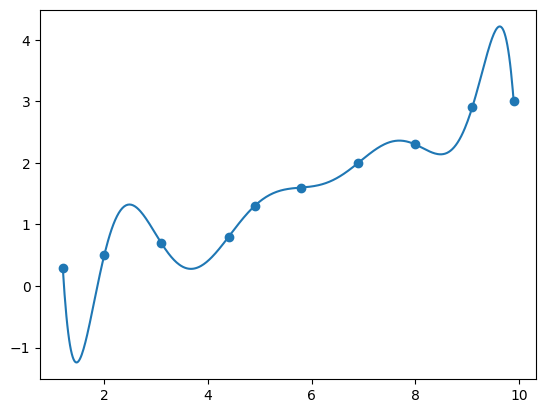

In [3]:
import matplotlib.pyplot as plt
x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

def solve_interpolation(x, y):
    coeffs=np.linalg.solve(np.vander(x, increasing=True), y)
    return coeffs

coeffs=solve_interpolation(x, y)
x_plot=np.linspace(min(x), max(x), 500)
y_plot=np.zeros_like(x_plot)
for i in range(len(coeffs)):
    y_plot += coeffs[i] * (x_plot**i)

plt.scatter(x,y)
plt.plot(x_plot,y_plot)
print(coeffs)

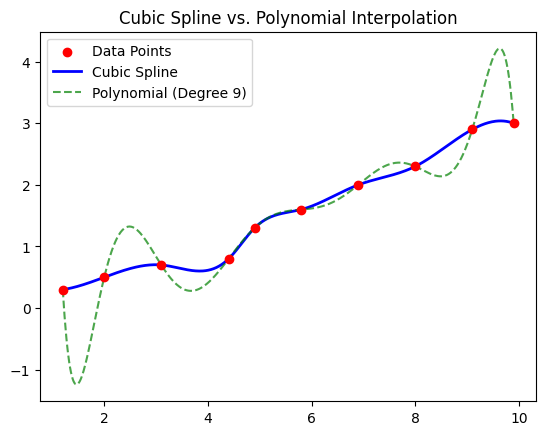

1.3333333333333333
1.3731301576003716
1.3744762382675273


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Define the data
x= np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y= np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

class interpolation:
    def __init__(self, x, y):
        self.x = x
        self.y = y
        V = np.vander(x, increasing=True)
        self.poly_coeffs = np.linalg.solve(V, y)
        
    def predict(self, x_val, method='spline'):
        """ Calculates Y_hat using the chosen interpolation method. """
        if method == 'linear':
            f = interp1d(self.x, self.y, kind='linear')
            return f(x_val)
        elif method == 'polynomial':
            return np.polyval(self.poly_coeffs[::-1], x_val)
        elif method == 'spline':
            f = interp1d(self.x, self.y, kind='cubic')
            return f(x_val)
        else:
            raise ValueError("Method must be 'linear', 'polynomial', or 'spline'")

interp_obj=interpolation(x, y)
x_smooth = np.linspace(x.min(), x.max(), 500)
y_spline = interp_obj.predict(x_smooth, 'spline')
y_poly = interp_obj.predict(x_smooth, 'polynomial')

plt.scatter(x, y, color='red', label='Data Points', zorder=5)
plt.plot(x_smooth, y_spline, label='Cubic Spline', color='blue', linewidth=2)
plt.plot(x_smooth, y_poly, label='Polynomial (Degree 9)', color='green', linestyle='--', alpha=0.7)
plt.title('Cubic Spline vs. Polynomial Interpolation')
plt.legend()
plt.show()

X_hat=5
print(interp_obj.predict(X_hat, 'linear'))
print(interp_obj.predict(X_hat, 'polynomial'))
print(interp_obj.predict(X_hat, 'spline'))

Leastsq results: a=69.93819295572497, b=64.13233139255135
Curve_fit results: a=69.93784038489176, b=64.13234086711788


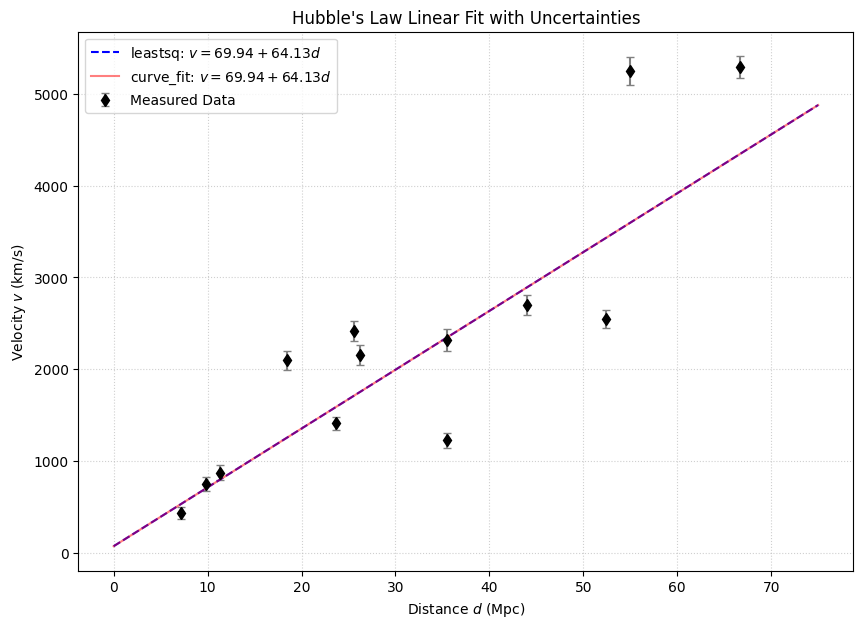

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import leastsq, curve_fit

data = np.array([
   18.49,     2094.75,    0.3,           100,
   35.48,     2320.87,    2.2,           120,
   35.48,     1224.9,     3.0,           80,
   11.34,     872.13,     1.2,           80,
   7.12,      432.2,      0.4,           70,
   9.82,      751,        0.3,           75,
   23.66,     1410,       2.3,           70,
   44,        2700,       4.0,           110,
   66.7,      5292,       5.3,           120,
   52.4,      2550,       5.2,           100,
   55,        5253,       6.1,           150,
   25.6,      2419,       3.2,           110,
   26.19,     2158,       2.8,           110
]).reshape(-1, 4)

d=data[:,0]
v=data[:,1]
d_err=data[:,2]
v_err=data[:,3]

def residuals(params, x, y, y_err):
    a, b = params
    model = a + b * x
    return (y - model) / y_err

params_lsq, _ = leastsq(residuals, [0, 70], args=(d, v, v_err))
a_lsq, b_lsq = params_lsq
def model(x, a, b):
    return a + b * x

params_cf, _ = curve_fit(model, d, v, sigma=v_err, absolute_sigma=True)
a_cf, b_cf = params_cf
print(f"Leastsq results: a={a_lsq}, b={b_lsq}")
print(f"Curve_fit results: a={params_cf[0]}, b={params_cf[1]}")

d_fit = np.linspace(0, 75, 100)
v_fit_lsq = a_lsq + b_lsq * d_fit
v_fit_cf = a_cf + b_cf * d_fit

plt.figure(figsize=(10, 7))
plt.errorbar(d, v, yerr=v_err, fmt='d', color='black', ecolor='gray', 
             capsize=3, label='Measured Data')
plt.plot(d_fit, v_fit_lsq, label=f'leastsq: $v = {a_lsq:.2f} + {b_lsq:.2f}d$', 
         color='blue', linestyle='--')
plt.plot(d_fit, v_fit_cf, label=f'curve_fit: $v = {a_cf:.2f} + {b_cf:.2f}d$', 
         color='red', alpha=0.5)
plt.xlabel('Distance $d$ (Mpc)')
plt.ylabel('Velocity $v$ (km/s)')
plt.title("Hubble's Law Linear Fit with Uncertainties")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [29]:
import numpy as np

def bilinearIP(I, col, row): # Make it X, Y compatible
    '''I is a two dimensional array and iF,jF is the position at
       which we want to interpolate. 'iF' must be bigger or equal to 0 and
       smaller than the highest index of I in i. The same applies for jF'''
    rowlen, collen= I.shape
    i = int(row)
    j = int(col)
    if row - i == 0 and col - j == 0:  # Falls exactly on a gridpoint
        return I[i,j]

    inbounds = (0 <= j <= collen-1) and (0 <= i <= rowlen-1)
    if not inbounds:
        Iintp = None
    else:
        mu =  row - i
        Lambda = col - j
        # If we are at the last pixel at the right or bottom, then there
        # is not a neighbour, so we take the pixel itself as the neighbour
        I0 = I[i,j]
        I1 = I[i,min(j+1,collen-1)]
        I2 = I[min(i+1,rowlen-1),j]
        I3 = I[min(i+1,rowlen-1),min(j+1,collen-1)]
        Iintp = (1-Lambda)*(1-mu)*I0 + Lambda*(1-mu)*I1 + mu*(1-Lambda)*I2 + Lambda*mu*I3
    return(Iintp)

I = np.array([[2.0,4.1], [2.5,3.8]])
print(I)

row_y = 0.7 # Row position is y value
col_x = 0.2  # Column position is x value

Iintp = bilinearIP(I, col_x, row_y)
if Iintp:
    print(f"The interpolated intensity at i,j={row_y},{col_x} => x, y={col_x}{row_y} is {Iintp:.6f}")
else:
    print("One of the indices was outside the limits")



[[2.  4.1]
 [2.5 3.8]]
The interpolated intensity at i,j=0.7,0.2 => x, y=0.20.7 is 2.658000
